The purpose of this notebook is to identify the spatial features of immune cells (particularly CD8 T cells) 
that can be used to predict the survival of colorectal cancer patients using Lasso Cox regression analysis.

In [1]:
# Load R packages
suppressPackageStartupMessages({
    
    library(readxl)
    library(magrittr)
    library(data.table)
    library(survival)
    library(glmnet)
    library(RColorBrewer)
    library(corrplot)
    library(dplyr)
    library(plyr)
    library(ggpubr)
    library(survminer)
    library(survivalROC)
    library(ggalt)
    library(rms)
}) 

### Data introduction    
The infiltration phenotype of CD8 T cells was calculated based on the spatial patterns of seven (7) types of cells defined by the expression patterns of three markers from multiplex IHC: CD8+PD-1+TIM-3+, CD8+PD-1+TIM-3−, CD8+PD-1−TIM-3−, CD8−PD-1+TIM-3+, CD8+PD-1−TIM-3+, CD8−PD-1+TIM-3−, and CD8−PD-1−TIM-3+. 

The spatial patterns of the immune cells were classified as intratumoral, proximal, and distal regions. The immune cells in the the distal regions were localized beyond the 30 μm radius from the tumor cells, whereas those in the proximal region were distributed within a 30 μm radius from the nuclear center of any given tumor cell. The i.t. region was the one in which T cells infiltrated the tumor epithelium.

The spatial distance parameters can be obtained with HALO software using the infiltration analysis of the spatial analysis module.

In [2]:
# Import meta data

meta <- readxl::read_xlsx("data/Meta_data.xlsx") %>% as.data.table()
meta$Samplename <- paste0(meta$Image,"_",meta$location)
setkey(meta,Samplename)

# Survial data
survival_dat <- Surv(meta$OS,meta$DEATH)%>%as.matrix()

if(all(survival_dat[, 'time'] == meta$OS)){
    
    rownames(survival_dat) <- meta$Samplename
}else{
    print('The two datasets do not match')
}

head(survival_dat, 3)

,time,status
TMA1_J-13,60,0
TMA2_A-11,60,0
TMA2_A-13,25,1


In [3]:
# Import the spatial IHC data
spatial_ihc <- readxl::read_xlsx("data/IHC_data.xlsx") %>% as.data.frame()
Rowname <- paste0(spatial_ihc$Image,"_",spatial_ihc$location)
rownames(spatial_ihc) <- Rowname
spatial_ihc <- spatial_ihc[,-c(1,2,21)]
#
colnames(spatial_ihc) <- gsub("infiltrated","proximal",colnames(spatial_ihc))
colnames(spatial_ihc) <- gsub("stromal","distal",colnames(spatial_ihc))
spatial_ihc %<>% as.matrix()

head(spatial_ihc, 3)

,CD8.distal,CD8PD1.distal,CD8PD1TIM3.distal,CD8TIM3.distal,CD8.proximal,CD8PD1.proximal,CD8PD1TIM3.proximal,CD8TIM3.proximal,PD1.distal,PD1TIM3.distal,⋯,PD1.proximal,PD1TIM3.proximal,TIM3.proximal,CD8.intratumoal,CD8PD1.intratumoal,CD8PD1TIM3.intratumoal,CD8TIM3.intratumoal,PD1TIM3.intratumoal,TIM3.intratumoal,PD1.intratumoal
TMA4_H-9,6,0,0,0,4,0,0,0,20,0,⋯,10,0,13,0,0,0,0,0,7,2
TMA3_I-5,34,8,2,2,48,5,3,8,314,3,⋯,207,6,254,19,39,0,1,10,45,2
TMA4_H-6,0,0,0,0,1,0,0,0,62,3,⋯,26,0,2,2,21,2,1,2,15,5


In [4]:
# Convert the cell count to percentage
percent_dat <- spatial_ihc %>%as.data.frame()
percent_dat$rowsum <- rowSums(percent_dat) %>% as.character()
percent_dat$Samplename <- rownames(percent_dat)
percent_dat <- melt(percent_dat) %>% as.data.table()
percent_dat$rowsum %<>% as.numeric()
percent_dat$percentage <- percent_dat$value/percent_dat$rowsum
percent_dat <- percent_dat[,c("Samplename","variable","percentage")]
percent_dat <- reshape2::dcast(percent_dat,formula = variable~Samplename,value.var = "percentage")
rownames(percent_dat) <- percent_dat$variable
percent_dat <- percent_dat[,-1]

percent_dat[1:3, 1:5]

Warning message in melt.default(percent_dat):
“The melt generic in data.table has been passed a data.frame and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is superseded and is no longer actively developed, and this redirection is now deprecated. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace, i.e. reshape2::melt(percent_dat). In the next version, this warning will become an error.”
Using rowsum, Samplename as id variables



,TMA1_J-13,TMA2_A-11,TMA2_A-13,TMA2_A-15,TMA2_A-17
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CD8.distal,0.048267327,0,0.03125,0.01190476,0
CD8PD1.distal,0.002887789,0,0.00000,0.00000000,0
CD8PD1TIM3.distal,0.002475248,0,0.00000,0.00000000,0


In [5]:
# Replace missing values with the medium 
percent_dat_new <- lapply(rownames(percent_dat), function(x){
           DF <- percent_dat[x,]
           DF[which(DF==0)] <- median(DF%>%as.numeric())
           return(DF)
}
)

percent_dat_new <- do.call(rbind,percent_dat_new)
percent_dat <- percent_dat_new

percent_dat[1:3, 1:5]

,TMA1_J-13,TMA2_A-11,TMA2_A-13,TMA2_A-15,TMA2_A-17
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CD8.distal,0.048267327,0.018181818,0.031250000,0.011904762,0.018181818
CD8PD1.distal,0.002887789,0.003196347,0.003196347,0.003196347,0.003196347
CD8PD1TIM3.distal,0.002475248,0.000000000,0.000000000,0.000000000,0.000000000


In [6]:
# Split the data into training and test data

#
set.seed(321)
ind <- sample(x=c(1,2), size = ncol(percent_dat), replace = TRUE, prob = c(0.6,0.4))
head(ind)

[1] 2 2 1 1 1 1

In [7]:
# Training data
train_dat <- percent_dat[,ind==1] %>% t() %>% as.data.frame()

train_dat$stage <- meta[rownames(train_dat)]$stage
train_dat%<>%as.matrix()

stopifnot(colnames(percent_dat)==meta$Samplename)
train_survival_dat <- survival_dat[ind==1, ] 
stopifnot(rownames(train_dat)==rownames(train_survival_dat))

# test data
test_dat <- percent_dat[,ind==2] 
test_dat%<>%t()%>%as.data.frame()
test_dat$stage <- meta[rownames(test_dat)]$stage
test_dat%<>%as.matrix()
stopifnot(colnames(percent_dat)==meta$Samplename)
test_survival_dat <- survival_dat[ind==2, ] 
stopifnot(rownames(test_dat)==rownames(test_survival_dat))

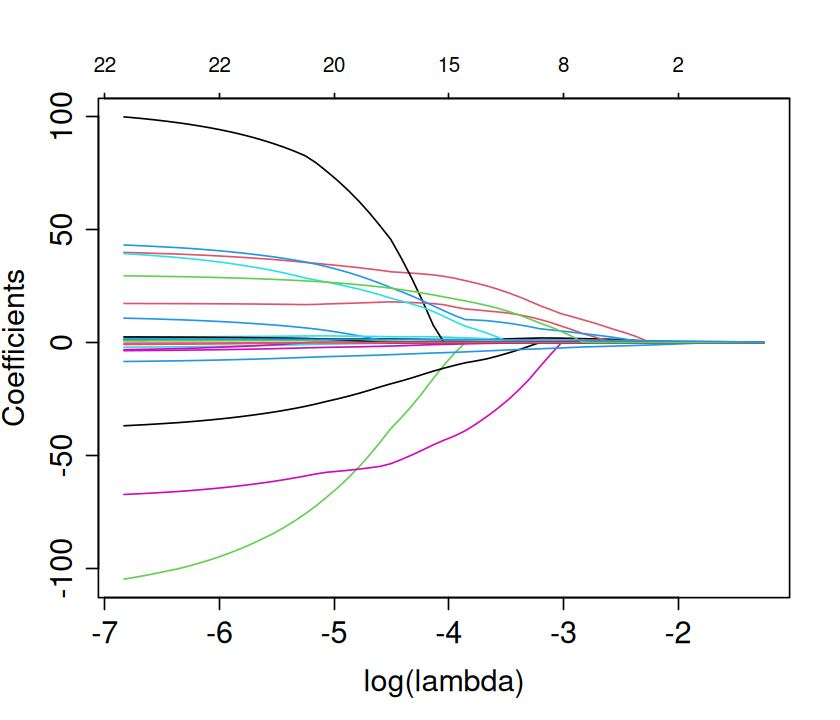

In [8]:
# Fit the Lasso Cox model
options(rerp.plot.width = 8, repr.plot.height = 6)
set.seed(123)
fit <- glmnet::glmnet(x = train_dat, y = train_survival_dat, 
                      family = "cox",nlambda = 100,alpha = 1,
                      standardize=T)

plot(fit, xvar = "lambda", label = F, cex.lab=1.5, cex.axis=1.5, xlab="log(lambda)")



plot the coefficients against log lambda

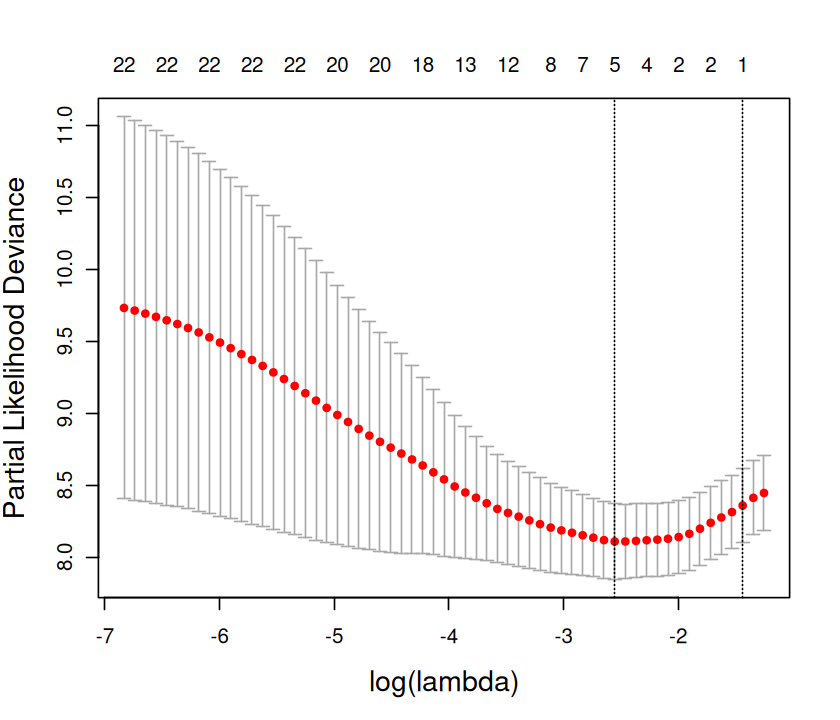

In [9]:
set.seed(123)
cvfit <- cv.glmnet(train_dat, train_survival_dat, family = "cox",type.measure = "deviance",
                   nfolds =10,alpha = 1,nlambda =100,standardize=T)

plot(cvfit,cex.lab=1.4, cex.axis = 1, xlab="log(lambda)") 


The model with the best performance (the smallest partial likelihood  deviance) was achieved when Logλ = −2.55 was used.

In [10]:
coef_df <- coef(cvfit, s = "lambda.min") %>%
  as.matrix() %>% as.data.frame() %>%
  tibble::rownames_to_column(var = "feature") %>%
  dplyr::rename(coefficient =`1`) %>%
  dplyr::filter(coefficient != 0)
coef_df$coefficient <- round(coef_df$coefficient, 1)

coef_df

feature,coefficient
<chr>,<dbl>
CD8.distal,1.3
CD8PD1.distal,5.7
PD1TIM3.distal,2.2
CD8PD1.intratumoal,-1.6
stage,0.9


Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as of ggplot2 3.3.4.”


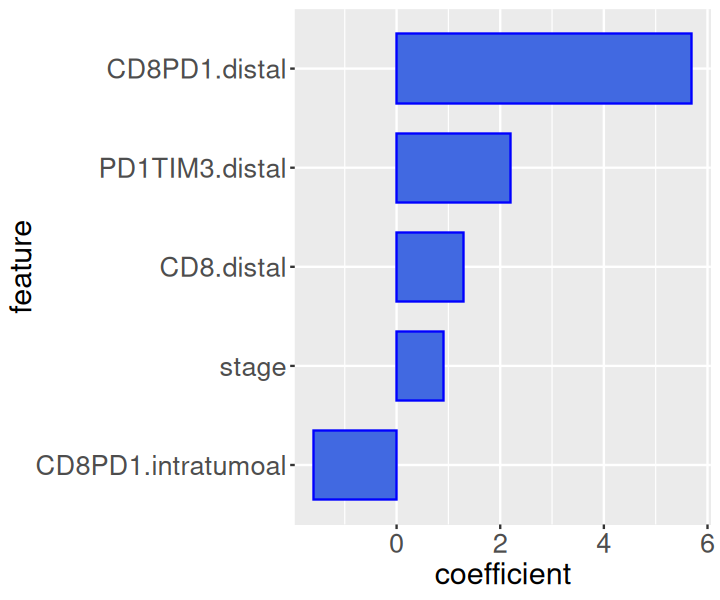

In [11]:
# Plot the coefficients of the features from the best model
plot_coef_df <- coef_df %>% arrange(coefficient)
plot_coef_df$feature <- factor(plot_coef_df$feature, levels = unique(plot_coef_df$feature))

options(repr.plot.width = 6, repr.plot.height = 5)
ggplot(data= plot_coef_df,                       # plot coefficients
       aes(x=feature, y=coefficient)) +
       coord_flip() +         
       geom_bar(stat='identity', 
                fill='royalblue', 
                color='blue', 
                width = 0.7) +
        guides(fill=FALSE) + 
# theme_classic() +
theme(
  axis.title.x = element_text(size = 18),
  axis.title.y = element_text(size = 18), 
    axis.text.y = element_text(size = 16),   
    axis.text.x = element_text(size = 16))


The above data show that The CD8+ distal, CD8+PD-1+ distal, PD-1+TIM-3+ distal, and CD8+PD-1+ intratumor are associated with patients' survival.

CD8+PD-1+ intratumor negatively affects the survival of colorectal cancer patients, whereas the other four features play opposite roles.

In [12]:
#
train_dat %<>%as.data.frame()
train_dat$time <- train_survival_dat[,"time"]
train_dat$status <- train_survival_dat[,"status"]
train_dat$Sample <- rownames(train_dat)
#
test_dat %<>%as.data.frame()
test_dat$time <- test_survival_dat[,"time"]
test_dat$status <- test_survival_dat[,"status"]
test_dat$Sample <- rownames(test_dat)

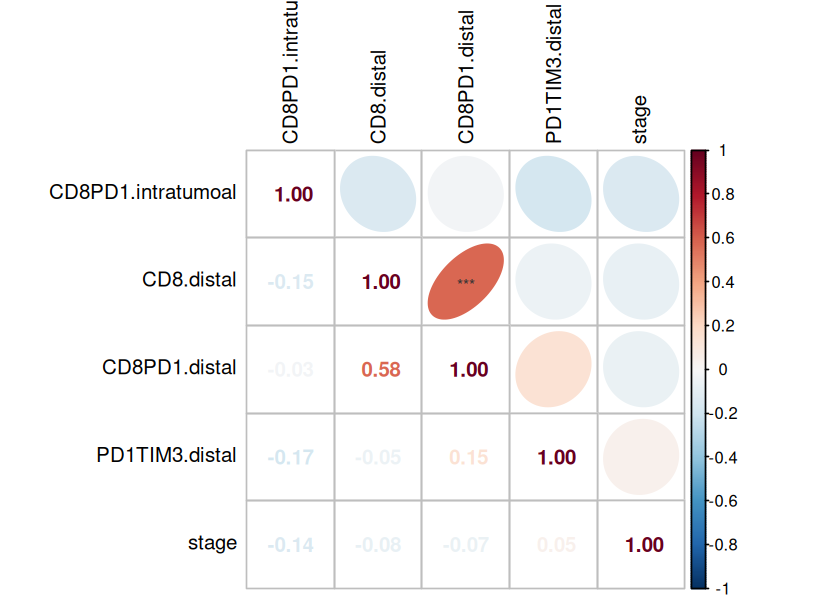

In [13]:
# Check the collinearity of the selected features
options(repr.plot.width = 7, repr.plot.height = 5)
train_dat$stage %<>%as.numeric()
cormat <- cor(train_dat[,coef_df$feature],method="pearson")
corpvalue <- cor.mtest(train_dat[,coef_df$feature],method="pearson")
col  <-  colorRampPalette(rev(brewer.pal(n = 11, name ="RdBu")))(200) 


corrplot(cormat,type = "upper", method = "ellipse",order ="hclust",
         p.mat = corpvalue$p,sig.level = c(0.001, 0.01, 0.05), 
         pch.cex = .8, insig = 'label_sig', pch.col = 'grey20',
         col = col,
         addCoef.col=NULL,
         diag =T,
         tl.col ="black",
          tl.pos = "tl"
         )
corrplot(cormat, type = "lower", method = "number", addCoef.col=NA,
         col = col, tl.col = "black",order ="hclust",
         tl.pos = "n",cl.pos = "n",
         add = TRUE)

No significant correlation was found among the selected features, except that there is a moderate correlation between CD8+ distal and CD8+PD-1+ distal.